In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(stringr)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [2]:
pep_rich <- readRDS('../Fig2g_h_VST3/vst3_with_tcr.rds')

In [3]:
pep_rich <- subset(pep_rich, pep_enriched == 'Pep-Enriched')

In [4]:
pep_rich$Stemness_Concentration <- paste(pep_rich$Stemness,pep_rich$Concentration, sep='_')

In [5]:
table(pep_rich$Stemness_Concentration)


       DMSO_NA          NA_NA  TWS-119_10_uM   TWS-119_1_uM   TWS-119_5_uM 
         23713          51089            563           7212             49 
UK5099_12.5_uM   UK5099_25_uM   UK5099_50_uM 
         10364           9898          15362 

In [6]:
pep_rich <- subset(pep_rich, Stemness_Concentration %in% c('TWS-119_5_uM','TWS-119_10_uM'), invert = T)

In [7]:
table(pep_rich$Peptide)


   Pep+ Pep_neg 
 114208    3394 

In [8]:
pep_rich <- subset(pep_rich, Peptide == 'Pep+')

Warning message:
“Removing 36 cells missing data for vars requested”


In [9]:
pep_rich <- JoinLayers(pep_rich)

In [10]:
library(harmony)

Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.4.3”


In [11]:
pep_rich <- NormalizeData(pep_rich) %>% FindVariableFeatures() %>% ScaleData()

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”


In [12]:
s.genes <- cc.genes$s.genes
g2m.genes <- cc.genes$g2m.genes

In [13]:
pep_rich <- CellCycleScoring(pep_rich, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The following features are not present in the object: MLF1IP, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: FAM64A, HN1, not searching for symbol synonyms”


In [14]:
pep_rich <- ScaleData(pep_rich, vars.to.regress = c("S.Score","G2M.Score"), features = VariableFeatures(pep_rich))

Regressing out S.Score, G2M.Score

Centering and scaling data matrix



In [15]:
pep_rich <- RunPCA(pep_rich, features = VariableFeatures(pep_rich)) %>% RunHarmony("Donor") %>% 
    RunUMAP(reduction = 'harmony', dims=1:25)

PC_ 1 
Positive:  CCL4, TNFAIP3, KDM5D, UTY, HAVCR2, KLRG1, FGL2, LILRB1, DDX3Y, IFI44 
	   IFI44L, MT-ND3, EIF1AY, AK1, LINC02694, GNLY, ARL6IP1, PATL2, PRDM1, GPR141 
	   CSGALNACT1, SYCP2, ARHGAP11B, CX3CR1, PLEKHA5, PDCD1, NTNG2, FCGR3A, KLRB1, PLXND1 
Negative:  LDHB, EBP, HSP90AB1, ENO1, OAZ1, FTL, FASN, PKM, ACTG1, UBA52 
	   S100A10, SCD, ACAT2, ARHGDIB, NME2, H2AZ1, SRI, SNX10, TMSB10, YWHAQ 
	   SET, EIF4A1, TUBA1B, RACK1, COTL1, LMNB1, ATP5MC3, DDX21, DPP4, PRDX1 
PC_ 2 
Positive:  MT-ND3, MT-ND2, MT-CYB, MT-ATP6, MT-ND4, MT-CO2, MT-ND4L, MT-ND5, MT-CO3, MT-ND1 
	   MT-CO1, EIF1AY, S1PR1, CCND2, DDX3Y, GPR183, KDM5D, KLF2, ITGA4, VIM 
	   UTY, ARL4C, MT-ND6, FGL2, CCR4, MYB, ANXA2, PRDM1, RASGRP2, GNLY 
Negative:  KLRC4, PIK3AP1, SCD, AIF1, CD300A, SERPINB9, XCL2, HMGCS1, SREBF1, CD160 
	   IDH2, FADS2, HOPX, CYRIA, GZMM, GZMK, TFEC, FADS1, CLU, CD27 
	   FLT4, SREBF2, MGAT1, ITGAX, EOMES, PTPN20, H2BC9, RNF138, LSS, TESC 
PC_ 3 
Positive:  H2BC9, H1-5, H4C3, H1-2, H1-4, RRM

In [16]:
pep_rich <- FindNeighbors(pep_rich, dims=1:25, reduction='harmony') %>% FindClusters(repep_richlution = 0.5)

Computing nearest neighbor graph

Warning message:
“package ‘future’ was built under R version 4.4.3”
Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 114208
Number of edges: 2288891

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8237
Number of communities: 14
Elapsed time: 51 seconds


4 singletons identified. 10 final clusters.



In [21]:
pep_rich <- FindClusters(pep_rich, repep_richlution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 114208
Number of edges: 2288891

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8237
Number of communities: 14
Elapsed time: 54 seconds


4 singletons identified. 10 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



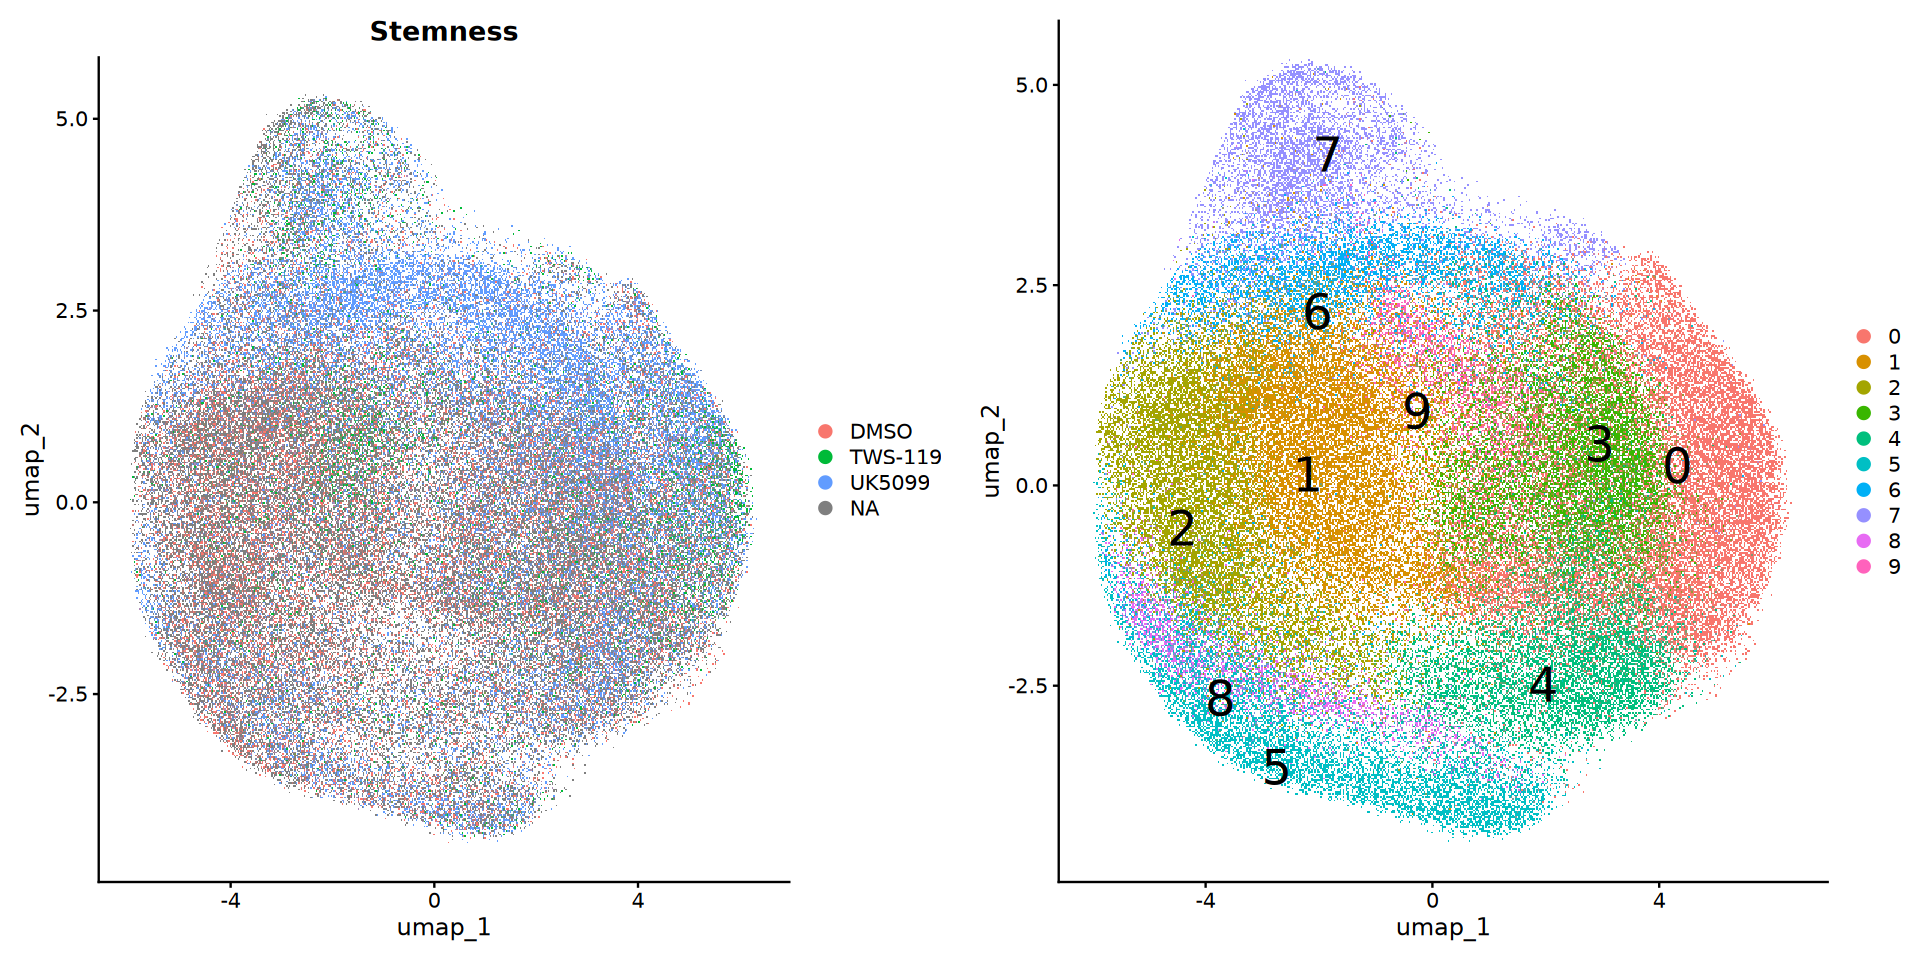

In [91]:
options(repr.plot.width = 16, repr.plot.height = 8)
p1 <- DimPlot(pep_rich, group.by = 'Stemness')
p2 <- DimPlot(pep_rich, label=T, label.size = 10, repel = T)
plot_grid(p1,p2,ncol=2)

In [203]:
# Open the PDF graphics device
pdf("plots/Fig2g_cluster_umap.pdf", width = 8, height = 8) # You can specify width and height in inches

# Create your plot
DimPlot(pep_rich, label=T, label.size = 10, repel = T, raster = F)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [109]:
saveRDS(pep_rich, 'pep_rich_cluster.rds')

In [2]:
pep_rich <- readRDS('pep_rich_cluster.rds')

# DEGs by Cluster

In [48]:
cluster_degs <- FindAllMarkers(pep_rich)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9



In [49]:
head(cluster_degs)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
TYMS,0,-1.606838,0.231,0.786,0,0,TYMS
LMNB1,0,-1.582057,0.279,0.802,0,0,LMNB1
TUBA1B,0,-1.745262,0.246,0.769,0,0,TUBA1B
PCLAF,0,-1.446677,0.221,0.740,0,0,PCLAF
MKI67,0,-1.553571,0.285,0.798,0,0,MKI67
NCAPG2,0,-1.487476,0.204,0.717,0,0,NCAPG2


In [134]:
top_up <- cluster_degs %>%
    filter(avg_log2FC > 1) %>%
    group_by(cluster) %>%
    arrange(p_val_adj, desc(avg_log2FC), .by_group = TRUE) %>%
    slice_head(n=5)            

In [135]:
top_up

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0.000000e+00,2.266646,0.141,0.072,0.000000e+00,0,ARRDC5
0.000000e+00,1.938434,0.225,0.135,0.000000e+00,0,SLC35D2
0.000000e+00,1.407849,0.995,0.999,0.000000e+00,0,CCL5
0.000000e+00,1.406123,0.327,0.235,0.000000e+00,0,CXCR6
0.000000e+00,1.353925,0.433,0.413,0.000000e+00,0,LINC02694
0.000000e+00,1.011882,0.428,0.231,0.000000e+00,1,H2BC3
0.000000e+00,2.421718,0.155,0.028,0.000000e+00,2,CKAP4
0.000000e+00,2.044709,0.105,0.021,0.000000e+00,2,CFI
0.000000e+00,2.016774,0.149,0.032,0.000000e+00,2,MYO1E


In [195]:
genes_oi_picks <- c('CCL5','CXCR6','CCR5','TNFAIP3','PDCD4',
                    'H2BC3','UBA52','ITGAX','CDKN2','TFEC',
                    'IL5','IL13','THY1','HSP90AB1','MYO1E',
                    'E2F7','RRM2','RAD51AP1','CDC25C','H2AX',
                    'MCM7','MCM5','E2F1','HELLS','UHRF1',
                    'CCNB1','CDC20','HMGB2','DDX21','CALR',
                    'IL7R','ABCG1','SLC7A11','SLC7A5','GPR55',
                    'CD40LG','TCF7','CCR7','IRF8','IL6R',
                    'CDC20','PLK1','AURKA','GAS2L3','CCNB1',
                    'EGR2','CRTAM','ZBED2','TNFRSF18','CCL3')

In [196]:
avg_exp <- AverageExpression(pep_rich, features = genes_oi_picks, group.by = 'seurat_clusters')

Warning message:
“The following 1 features were not found in the RNA assay: CDKN2”


In [197]:
avg_exp <- as.data.frame(avg_exp$RNA)

In [198]:
my_colors <- colorRampPalette(c("navy", "white", "red"))(50)

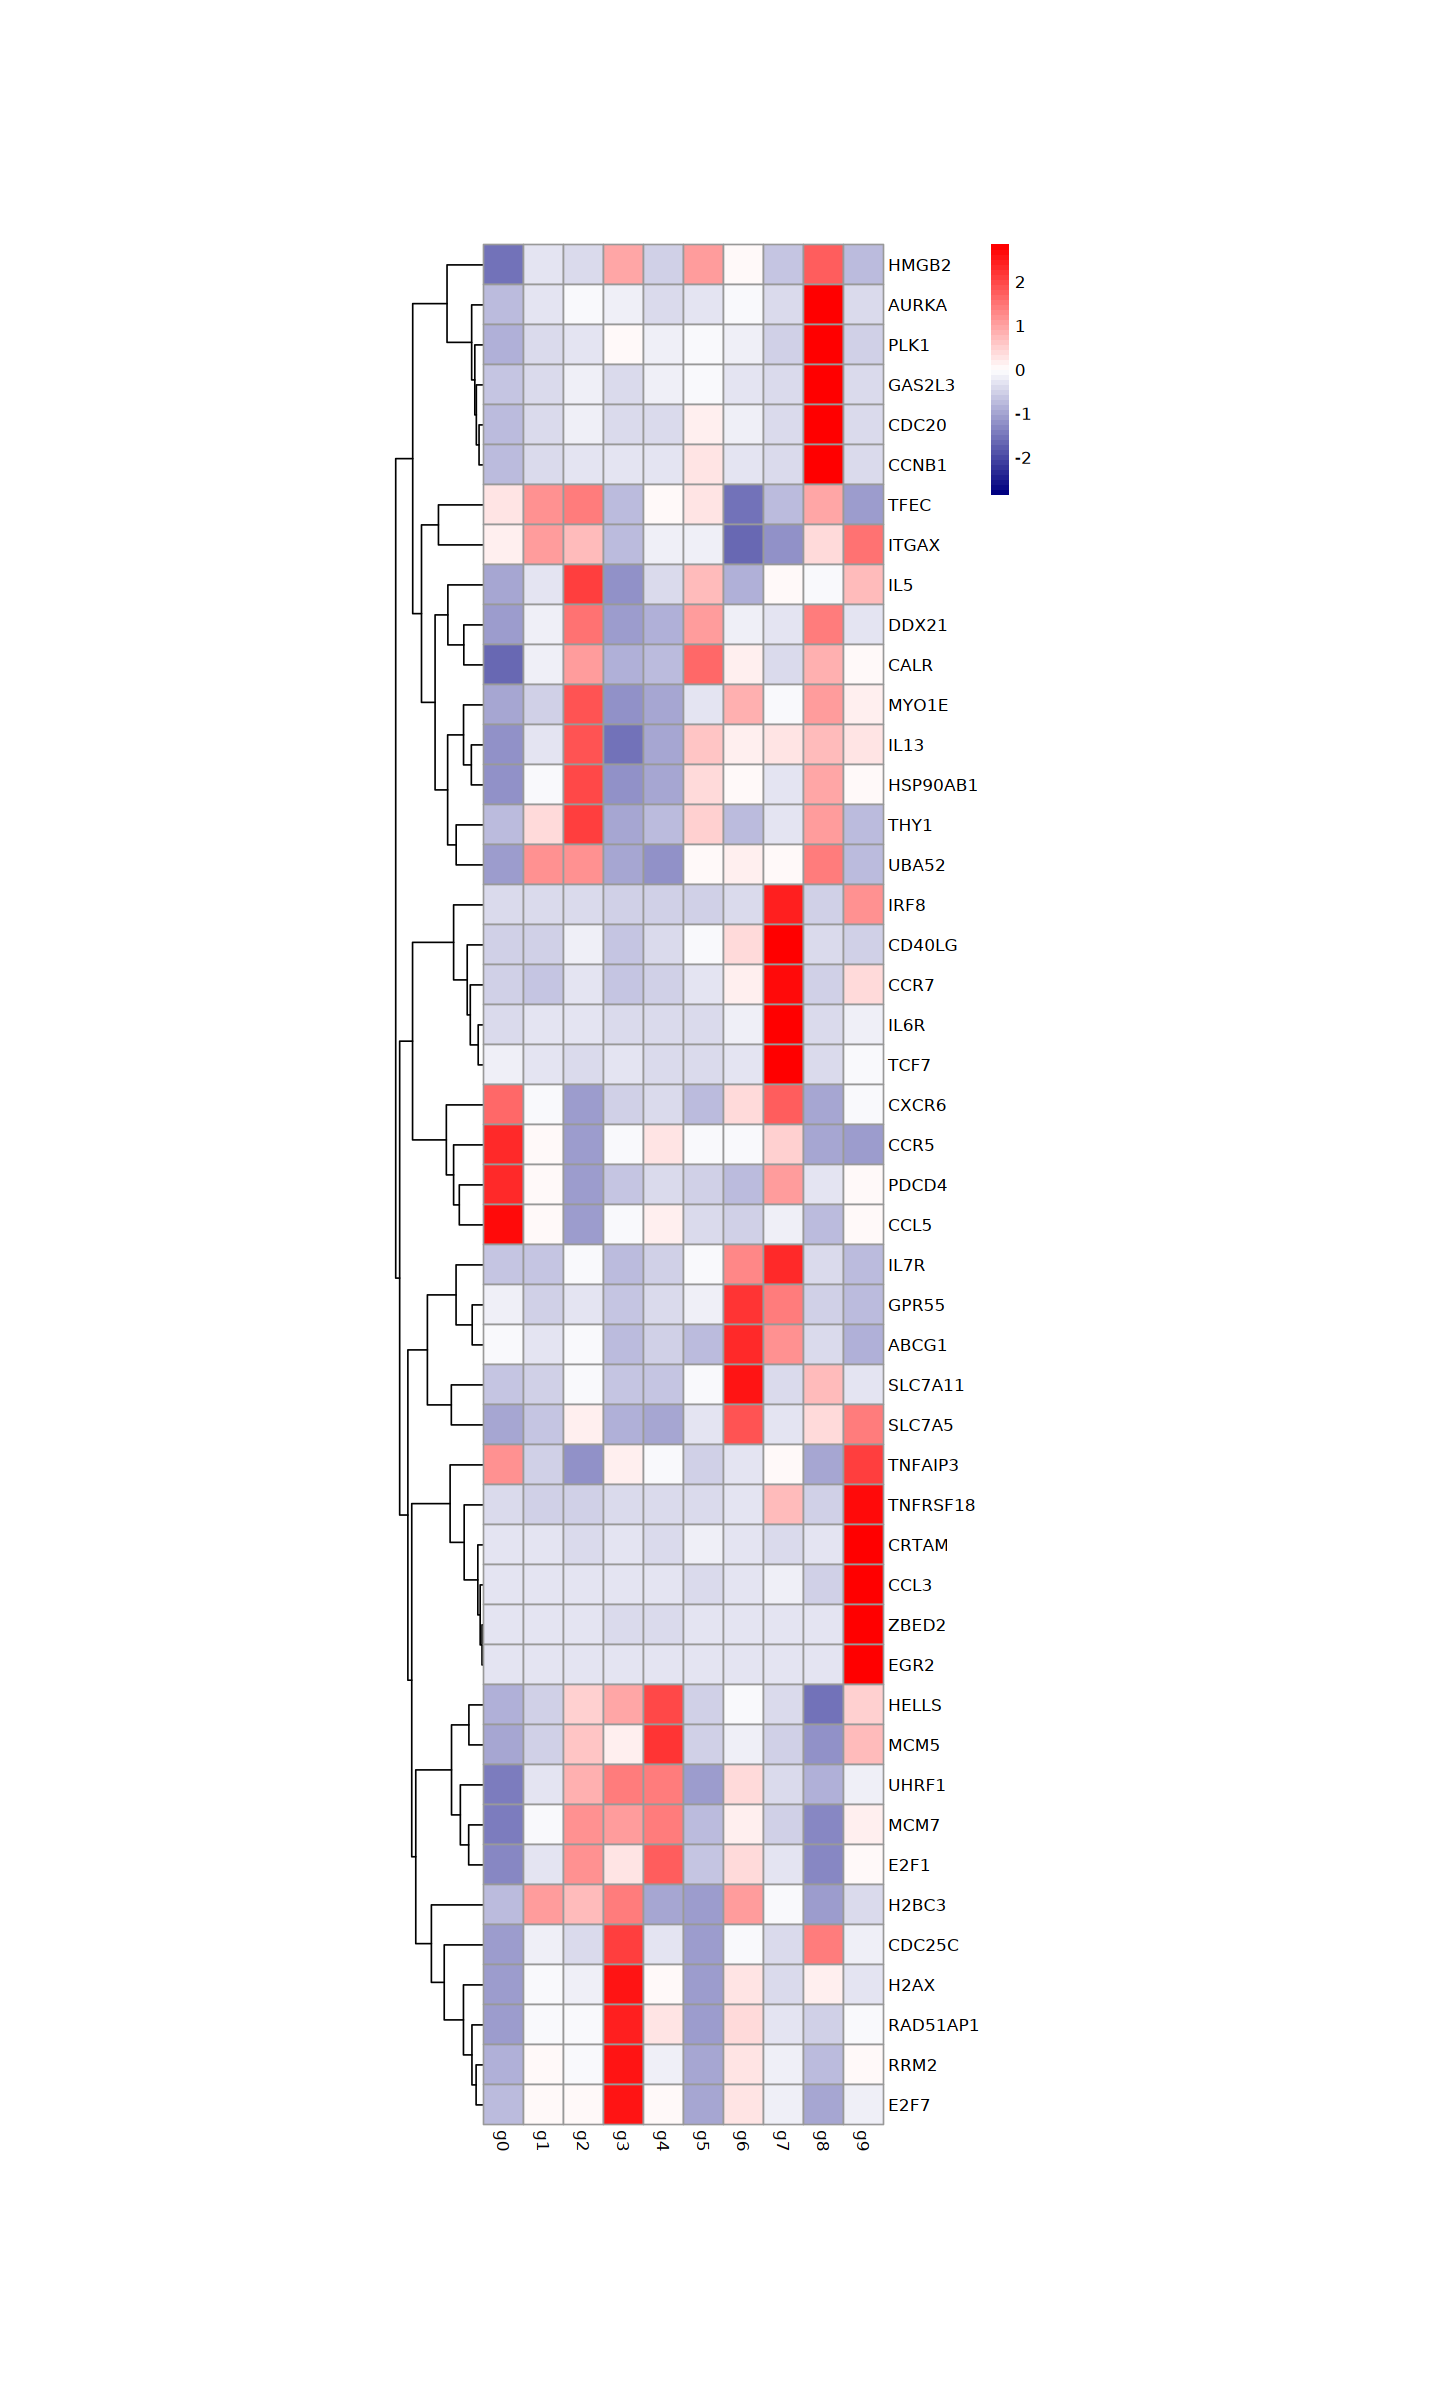

In [200]:
options(repr.plot.width = 12, repr.plot.height = 20)
p_heatmap <- pheatmap(avg_exp, scale = 'row', cluster_cols = F, cluster_rows = T,
                      color = my_colors, cellwidth = 24, cellheight = 24)

In [201]:
# Open the PDF graphics device
pdf("plots/Fig2g_cluster_heatmap.pdf", width = 12, height = 20) # You can specify width and height in inches

# Create your plot
print(p_heatmap)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

## Fig2g Cluster Distribution

In [83]:
cluster_summary <- pep_rich@meta.data %>%
    group_by(seurat_clusters, Stemness_Concentration) %>%
    summarise(count = n()) %>%
    group_by(Stemness_Concentration) %>%
    mutate(prop = count / sum(count))

`summarise()` has grouped output by 'seurat_clusters'. You can override using
the `.groups` argument.


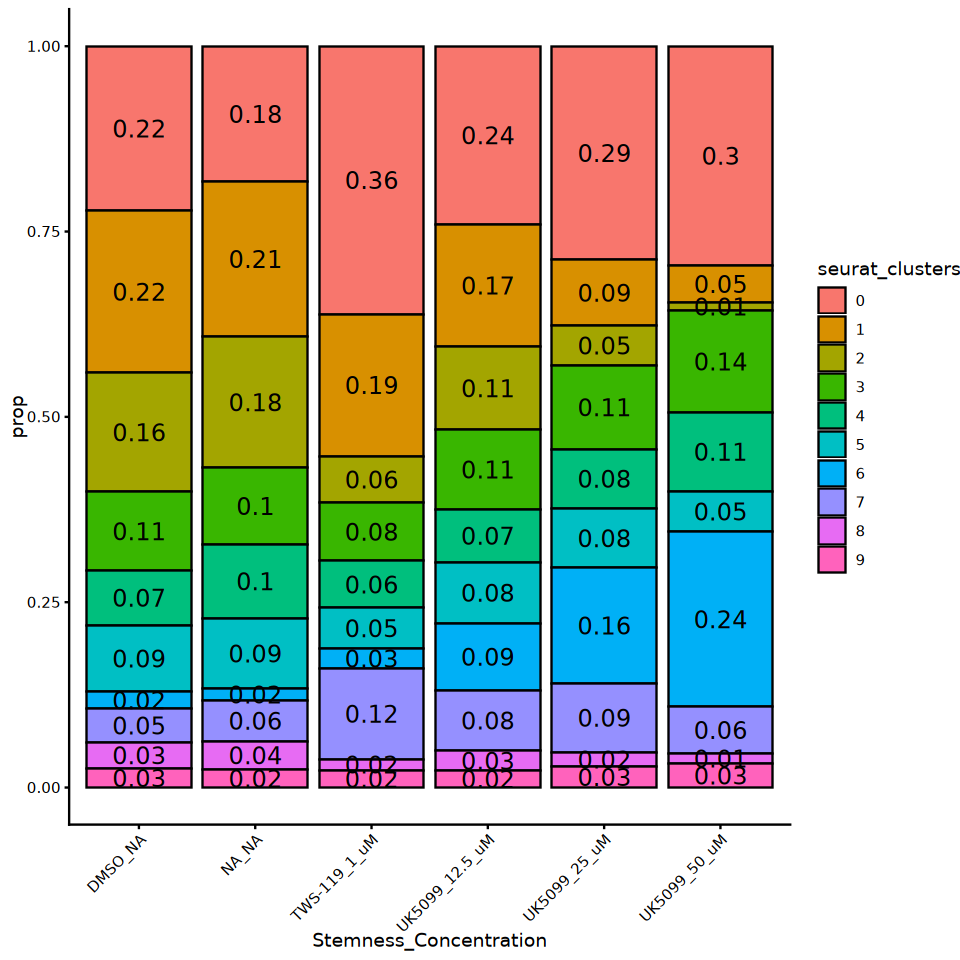

In [88]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(cluster_summary, aes(x=Stemness_Concentration, y=prop, fill = seurat_clusters)) + 
    geom_bar(stat='identity', color='black') + 
    geom_text(aes(label = round(prop,2)), size=5,
              position = position_stack(vjust=0.5)) +
    theme_classic() + RotatedAxis()

In [127]:
# Open the PDF graphics device
pdf("plots/Fig2g_barplot_cluster_proportions.pdf", width = 8, height = 8) # You can specify width and height in inches

# Create your plot
ggplot(cluster_summary, aes(x=Stemness_Concentration, y=prop, fill = seurat_clusters)) + 
    geom_bar(stat='identity', color='black') + 
    geom_text(aes(label = round(prop,2)), size=5,
              position = position_stack(vjust=0.5)) +
    theme_classic() + RotatedAxis()

# Close the graphics device to save the plot
dev.off()

pdf 
  2